Using device: cpu
loading annotations into memory...
Done (t=1.34s)
creating index...
index created!


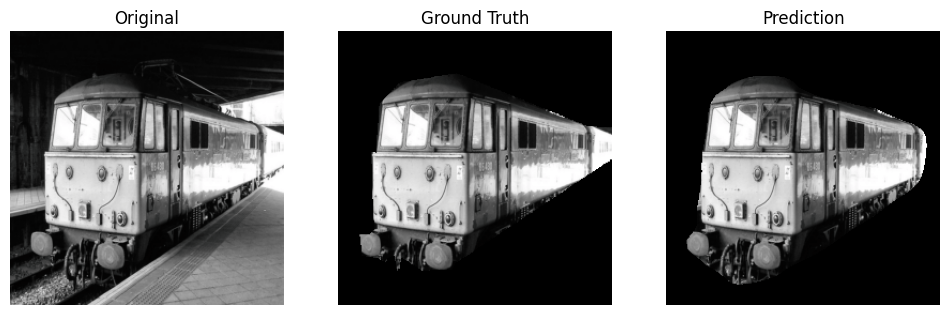

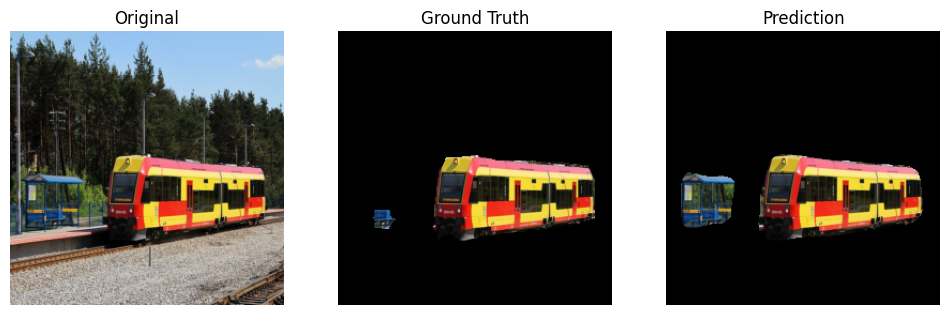

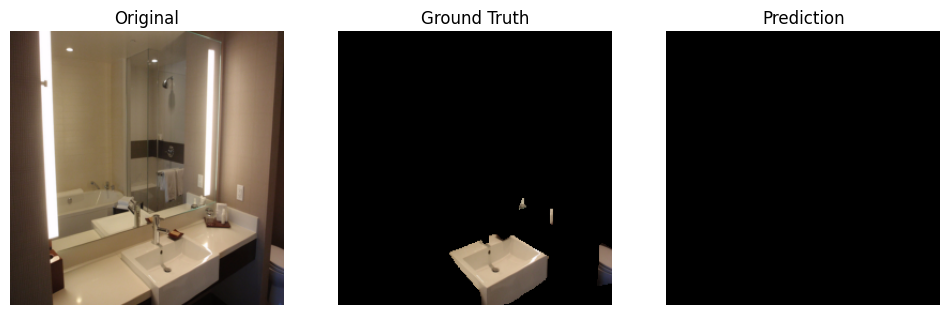

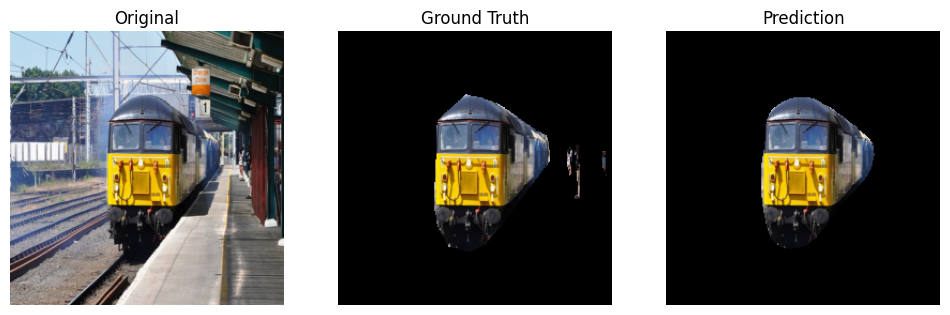

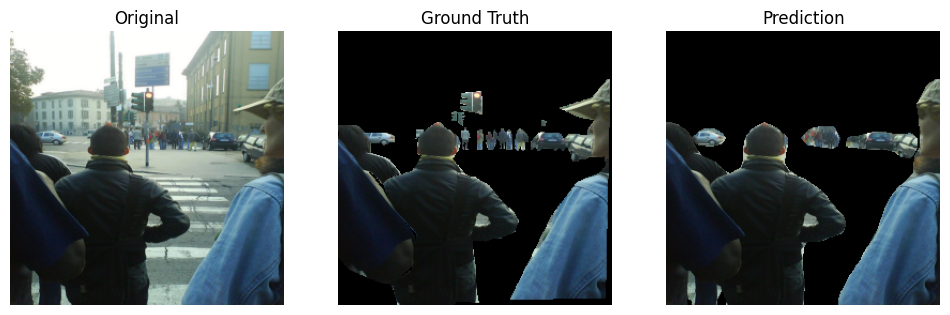

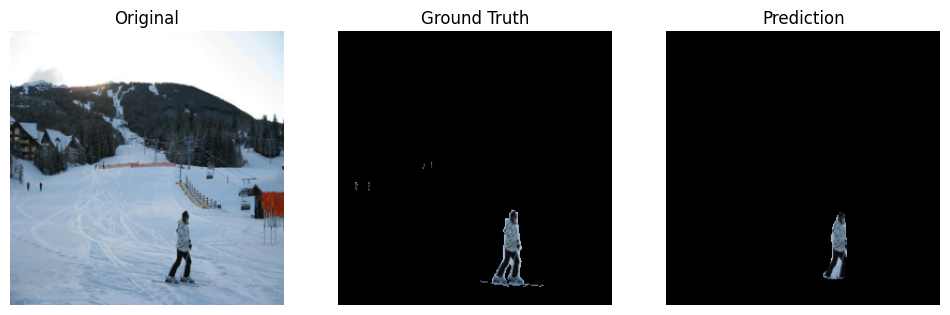

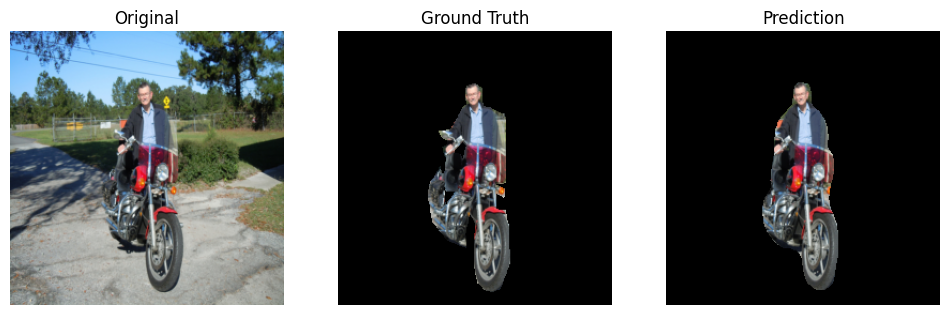

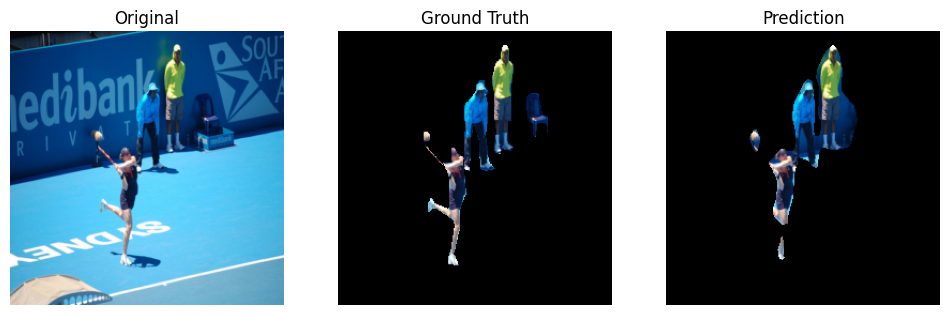

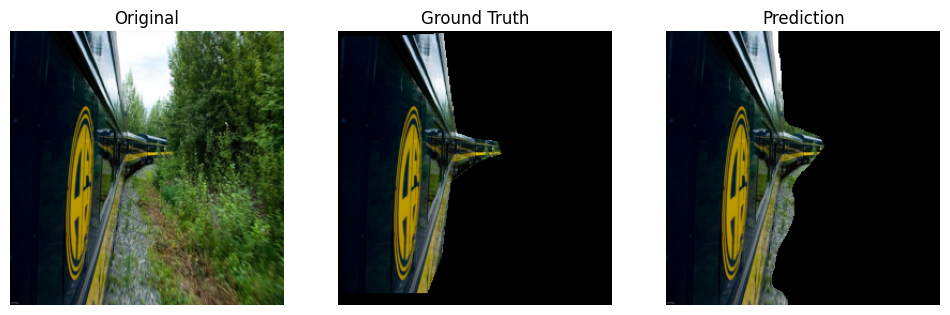

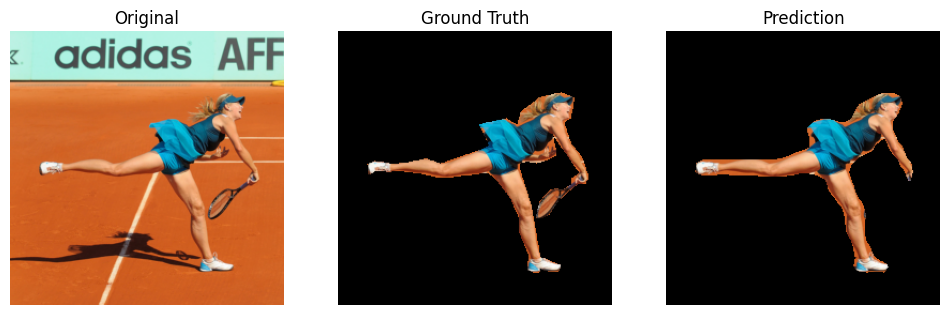


Average Pixel Accuracy: 0.9564
Average Binary IoU: 0.7105


In [51]:
import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pycocotools.coco import COCO
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =======================
# Step 1: Download COCO subset
# =======================
root = "./coco/val2017"
ann_dir = "./coco/annotations"
annFile = os.path.join(ann_dir, "instances_val2017.json")

def download_file(url, save_path):
    if not os.path.exists(save_path):
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, save_path)
        print("Download complete.")

# Download val images
if not os.path.exists(root):
    os.makedirs(root, exist_ok=True)
    url_images = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = "val2017.zip"
    download_file(url_images, zip_path)
    print("Extracting images...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path)

# Download annotations
if not os.path.exists(annFile):
    os.makedirs(ann_dir, exist_ok=True)
    url_ann = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    zip_path_ann = "annotations.zip"
    download_file(url_ann, zip_path_ann)
    print("Extracting annotations...")
    with zipfile.ZipFile(zip_path_ann, 'r') as zip_ref:
        zip_ref.extractall("./coco")
    os.remove(zip_path_ann)

# =======================
# Step 2: Dataset Class
# =======================
class CocoSegmentationDataset(Dataset):
    def __init__(self, root, annFile, image_size=256, transform=None, subset_size=20):
        self.coco = COCO(annFile)
        self.root = root
        self.transform = transform
        self.image_size = image_size

        self.img_ids = list(self.coco.imgs.keys())
        random.shuffle(self.img_ids)  # Shuffle to get different images
        self.img_ids = self.img_ids[:subset_size]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(path).convert("RGB")

        # Image transform
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(transforms.Resize((self.image_size, self.image_size))(image))

        # Binary mask creation
        mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
        for ann in anns:
            m = self.coco.annToMask(ann)
            m_resized = np.array(transforms.Resize((self.image_size, self.image_size),
                                                   interpolation=Image.NEAREST)(Image.fromarray(m)))
            mask = np.maximum(mask, m_resized)

        return image, torch.tensor(mask, dtype=torch.long)

# =======================
# Step 3: Transform & DataLoader
# =======================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_dataset = CocoSegmentationDataset(root, annFile, transform=transform, subset_size=20)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# =======================
# Step 4: Load Pretrained Model
# =======================
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.to(device)
model.eval()

# =======================
# Step 5: Utility Functions
# =======================
def extract_object_rgb(image, mask):
    obj = np.zeros_like(image, dtype=np.uint8)
    obj[mask > 0] = image[mask > 0]
    return obj

# Binary pixel accuracy
def pixel_accuracy(pred, target):
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

# Binary IoU
def binary_iou(pred, target):
    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()
    if union == 0:
        return 1.0  # perfect if both empty
    return intersection / union

# =======================
# Step 6: Visualization + Metrics
# =======================
def visualize_samples_and_metrics(model, data_loader, num_samples=5):
    model.eval()
    shown = 0
    total_pixel_acc = 0
    total_iou = 0
    count = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            outputs = model(images)["out"]

            # Prediction: binary mask (treat any class as object)
            preds = torch.argmax(outputs, dim=1).cpu()
            preds_binary = (preds > 0).long()

            for i in range(len(images)):
                if shown >= num_samples:
                    avg_pixel_acc = total_pixel_acc / count
                    avg_iou = total_iou / count
                    print(f"\nAverage Pixel Accuracy: {avg_pixel_acc:.4f}")
                    print(f"Average Binary IoU: {avg_iou:.4f}")
                    return

                # Prepare images for visualization
                img = images[i].cpu()
                img = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
                img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
                img = (img * 255).astype(np.uint8)

                gt_mask = masks[i].cpu()
                pred_mask = preds_binary[i]

                # Metrics
                total_pixel_acc += pixel_accuracy(pred_mask, gt_mask)
                total_iou += binary_iou(pred_mask, gt_mask)
                count += 1

                # Visualization
                gt_obj = extract_object_rgb(img, gt_mask.numpy())
                pred_obj = extract_object_rgb(img, pred_mask.numpy())

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
                axs[1].imshow(gt_obj); axs[1].set_title("Ground Truth"); axs[1].axis("off")
                axs[2].imshow(pred_obj); axs[2].set_title("Prediction"); axs[2].axis("off")
                plt.show()

                shown += 1

# =======================
# Step 7: Run
# =======================
visualize_samples_and_metrics(model, val_loader, num_samples=10)
